In [78]:
# Imports
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

# Load your parquet training dataset
df = pd.read_parquet("../data/train_NYC_inspection.parquet")

df.head(10)

,CUISINE DESCRIPTION,BORO,ZIPCODE,Latitude,Longitude,INSPECTION DATE,BUILDING,STREET,SCORE,GRADE
0,Chinese,Queens,11354.0,40.759778,-73.829235,2024-08-05,136-20,ROOSEVELT AVENUE,9.0,A
1,Coffee/Tea,Queens,11362.0,40.769834,-73.736180,2025-10-31,25201,NORTHERN BLVD,9.0,A
2,Japanese,Manhattan,10036.0,40.759161,-73.990369,2025-05-02,354,WEST 44 STREET,14.0,B
3,Pizza,Queens,11372.0,40.756245,-73.878681,2025-04-15,8906,NORTHERN BLVD,40.0,C
4,Chicken,Queens,11432.0,40.708211,-73.803110,2024-02-29,87-44,PARSONS BOULEVARD,20.0,None
5,"Juice, Smoothies, Fruit Salads",Brooklyn,11217.0,40.674889,-73.975183,2025-04-30,82,7 AVENUE,19.0,None
6,Chinese,Manhattan,10013.0,40.715443,-73.997951,2025-01-22,60,BAYARD STREET,39.0,None
7,Latin American,Bronx,NaN,0.000000,0.000000,2025-01-09,55925594,BROADWAY,24.0,None
8,Sandwiches,Manhattan,10003.0,40.736898,-73.990503,2025-02-12,39,UNION SQUARE WEST,8.0,A
9,Chicken,Queens,11432.0,40.703485,-73.799838,2025-04-17,15929,JAMAICA AVE,13.0,A


In [79]:
# Data Cleaning

# Data cleaning: drop rows with missing target (GRADE)
df = df.dropna(subset=["GRADE"])

# drop Score column as it is very correlated with target
df = df.drop(columns=["SCORE"])

# Impute remaining numeric missing values with median
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

In [80]:
# Define Features and Target

target_col = "GRADE"
y = df[target_col]

# Drop columns not used as features, including SCORE and target
X = df.drop(
    columns=[
        target_col,
        "SCORE",          
        "INSPECTION DATE",
        "BUILDING",
        "STREET"
    ],
    errors="ignore"     
)

# Encode categorical features: CUISINE DESCRIPTION and BORO
from sklearn.preprocessing import LabelEncoder

if "CUISINE DESCRIPTION" in X.columns:
    cuisine_encoder = LabelEncoder()
    X["CUISINE_ENCODED"] = cuisine_encoder.fit_transform(X["CUISINE DESCRIPTION"])
    X = X.drop(columns=["CUISINE DESCRIPTION"])

if "BORO" in X.columns:
    boro_encoder = LabelEncoder()
    X["BORO_ENCODED"] = boro_encoder.fit_transform(X["BORO"])
    X = X.drop(columns=["BORO"])

# Keep only numeric columns as final features
X = X.select_dtypes(include=["number"]).copy()

print("Number of numeric features:", X.shape[1])
print("Feature columns:", list(X.columns))

Number of numeric features: 5
Feature columns: ['ZIPCODE', 'Latitude', 'Longitude', 'CUISINE_ENCODED', 'BORO_ENCODED']


In [81]:
# Train–test split with stratification by grade
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts())

Train shape: (54738, 5)
Test shape: (13685, 5)
Class distribution in train:
 GRADE
A    34465
B     6487
C     5194
N     4435
Z     3918
P      239
Name: count, dtype: int64


In [82]:
# Pipeline with class_weight balanced
log_pipe_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=300,
        class_weight="balanced"   # <<< KEY ADDITION
    ))
])

# Hyperparameter grid
param_grid_balanced = {
    "logreg__C": [0.01, 0.1, 1.0]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
log_gs_balanced = GridSearchCV(
    estimator=log_pipe_balanced,
    param_grid=param_grid_balanced,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

log_gs_balanced.fit(X_train, y_train)

best_balanced = log_gs_balanced.best_estimator_
y_pred_balanced = best_balanced.predict(X_test)

print("Balanced Logistic Regression — Test Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))


Fitting 5 folds for each of 3 candidates, totalling 15 fits


/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/linear_model/

Balanced Logistic Regression — Test Accuracy: 0.22754841066861528
[[2426 1012  845 1750 2583    0]
 [ 390  215  185  292  540    0]
 [ 299  150  173  228  449    0]
 [ 234  155  126  277  317    0]
 [  16    7    4    9   23    0]
 [ 263  116  113  187  301    0]]
              precision    recall  f1-score   support

           A       0.67      0.28      0.40      8616
           B       0.13      0.13      0.13      1622
           C       0.12      0.13      0.13      1299
           N       0.10      0.25      0.14      1109
           P       0.01      0.39      0.01        59
           Z       0.00      0.00      0.00       980

    accuracy                           0.23     13685
   macro avg       0.17      0.20      0.13     13685
weighted avg       0.46      0.23      0.29     13685



/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/virtual_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

In [83]:
# Report best hyperparameters and cross-validated accuracy
best_C = log_gs_balanced.best_params_["logreg__C"]
best_cv_acc = log_gs_balanced.best_score_

print(f"Best C value: {best_C}")
print(f"Best cross-validated accuracy: {best_cv_acc:.4f}")

Best C value: 0.01
Best cross-validated accuracy: 0.2256


Test accuracy: 0.2275


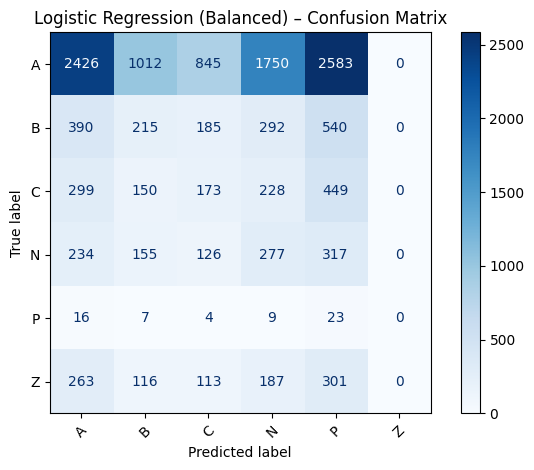

In [87]:
# Evaluate on test set
best_logreg = log_gs_balanced.best_estimator_

y_pred = best_logreg.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=sorted(y.unique()))
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Logistic Regression (Balanced) – Confusion Matrix")
plt.tight_layout()
plt.savefig("../output/figures/logreg_balanced_confusion_matrix.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [85]:
# Inspect learned coefficients
coef_matrix = best_logreg.named_steps["logreg"].coef_

print("Number of classes:", coef_matrix.shape[0])
print("Number of features:", coef_matrix.shape[1])

coefs = pd.DataFrame(
    coef_matrix,
    columns=X.columns,
    index=best_logreg.named_steps["logreg"].classes_
)

coefs

Number of classes: 6
Number of features: 5


,ZIPCODE,Latitude,Longitude,CUISINE_ENCODED,BORO_ENCODED
A,-0.095012,-0.091266,-0.010381,-0.040350,-0.044819
B,0.015964,0.012968,0.037142,0.001144,-0.055832
C,0.049862,0.087230,0.056879,0.007041,0.046444
N,-0.076364,-0.060869,-0.126167,0.066060,0.043335
P,0.133389,0.023676,-0.031031,-0.076113,-0.010631
Z,-0.027839,0.028261,0.073557,0.042219,0.021503


The Logistic Regression model uses L2 regularization to stabilize the learned coefficients and reduce overfitting when predicting inspection grades. The modeling pipeline standardizes all numeric features within the cross-validation loop to prevent data leakage and ensure that every hyperparameter setting is evaluated under identical preprocessing conditions. GridSearchCV tests multiple values of the regularization parameter C while using class weights to address imbalance, selecting the configuration that achieves the highest cross-validated accuracy. After tuning, the final model is evaluated on the test set using accuracy, a confusion matrix, and detailed classification metrics to understand which grades are predicted correctly and where errors occur. This workflow provides a structured and reproducible approach to building and analyzing a penalized classification model.